In [1]:
import torch

In [2]:
import pandas as pd
import numpy as np

In [3]:
FOLD = 0
input_dir = "/scratch1/smaruj/genomic_map_transformation"

df = pd.read_csv(f"{input_dir}/df_select_fold{FOLD}.tsv", sep="\t")

df['target_chrom'] = df['chrom'].shift(-1)
df['target_start'] = df['start'].shift(-1)
df['target_end'] = df['end'].shift(-1)

# Fill last row with values from the first row
df.loc[df.index[-1], 'target_chrom'] = df.loc[df.index[0], 'chrom']
df.loc[df.index[-1], 'target_start'] = df.loc[df.index[0], 'start']
df.loc[df.index[-1], 'target_end'] = df.loc[df.index[0], 'end']

# Convert to int
df['target_start'] = df['target_start'].astype(int)
df['target_end'] = df['target_end'].astype(int)

In [4]:
df.head()

,chrom,start,end,fold,target_chrom,target_start,target_end
0,chr5,63203328,64514048,fold0,chr3,138672128,139982848
1,chr3,138672128,139982848,fold0,chr5,43542528,44853248
2,chr5,43542528,44853248,fold0,chr3,115171328,116482048
3,chr3,115171328,116482048,fold0,chr7,61700096,63010816
4,chr7,61700096,63010816,fold0,chr4,141115392,142426112


In [5]:
seq_init = torch.load("/scratch1/smaruj/genomic_map_transformation/movie/seq_0.pt")    # initial sequence
seq_final = torch.load("/scratch1/smaruj/genomic_map_transformation/movie/seq_189.pt") # final edited sequence

In [6]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [7]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [8]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [9]:
from memelite import fimo

In [10]:
from pyfaidx import Fasta

In [12]:
genome = Fasta("/project2/fudenber_735/genomes/mm10/mm10.fa")

# Coordinates of tehe target
chrom = "chr5"
start = 43542528
end = 44853248

In [13]:
seq_target_str = genome[chrom][start:end].seq.upper()

In [14]:
def one_hot_encode(seq):
    mapping = {"A":0, "C":1, "G":2, "T":3}
    ohe = np.zeros((4, len(seq)), dtype=np.float32)
    for i, base in enumerate(seq):
        if base in mapping:
            ohe[mapping[base], i] = 1.0
    return ohe

In [15]:
seq_target = one_hot_encode(seq_target_str)

In [16]:
seq_target_tensor = torch.from_numpy(seq_target).float().unsqueeze(0)

### Original Seq

In [17]:
orig_hits = fimo(
    motifs=motifs_dict,
    sequences=seq_init.cpu(),
    threshold=1e-4,
    reverse_complement=True
)[0]

In [18]:
def ctcf_hits_from_fimo(fimo_df, seq_len=1310720, bin_size=2048):
    """
    Convert FIMO motif hits into binned counts per strand.

    fimo_df: DataFrame returned by fimo.fimo
        Must contain 'start', 'end', 'strand' columns.
    seq_len: int, total sequence length
    bin_size: int, size of each bin
    """
    n_bins = seq_len // bin_size
    hits_plus = np.zeros(n_bins)
    hits_minus = np.zeros(n_bins)

    for _, row in fimo_df.iterrows():
        # 0-based index of the start position
        bin_idx = int(row['start'] // bin_size)
        if bin_idx >= n_bins:
            continue
        if row['strand'] == '+':
            hits_plus[bin_idx] += 1
        else:
            hits_minus[bin_idx] += 1

    return hits_plus, hits_minus

In [19]:
ctcf_init_plus, ctcf_init_minus = ctcf_hits_from_fimo(orig_hits)

In [20]:
import matplotlib.pyplot as plt

def plot_ctcf(ctcf_plus, ctcf_minus, title="CTCF", bin_size=2048, save_path=None):
    NBINS = len(ctcf_plus)
    MAX_CTCF_HITS = max(ctcf_plus.max(), ctcf_minus.max()) + 1
    x = np.arange(NBINS)
    
    plt.figure(figsize=(15, 3))
    plt.bar(x, ctcf_plus, width=1.0, color='black', alpha=0.7, label='+ strand')
    plt.bar(x, -ctcf_minus, width=1.0, color='red', alpha=0.7, label='− strand')
    plt.axhline(0, color='gray', linewidth=0.5)
    plt.xlim(0, NBINS)
    plt.ylim(-4, 4)
    plt.xlabel(f"Input sequence (bin)")
    plt.ylabel("CTCF motifs number")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format="svg", bbox_inches="tight")
    
    plt.show()

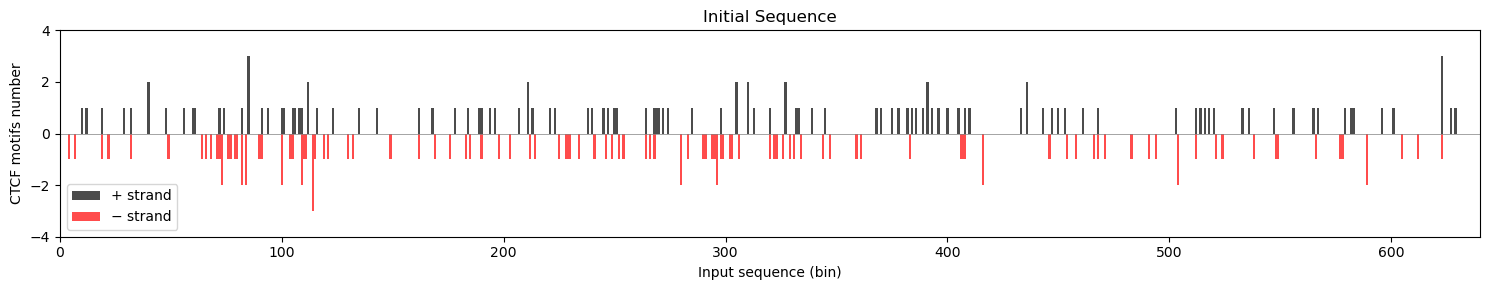

In [21]:
plot_ctcf(ctcf_init_plus, ctcf_init_minus, title="Initial Sequence", save_path="./original_seq_ctcf_track.svg")

### Final Seq

In [22]:
final_hits = fimo(
    motifs=motifs_dict,
    sequences=seq_final.cpu().detach().numpy(),
    threshold=1e-4,
    reverse_complement=True
)[0]

In [23]:
ctcf_final_plus, ctcf_final_minus = ctcf_hits_from_fimo(final_hits)

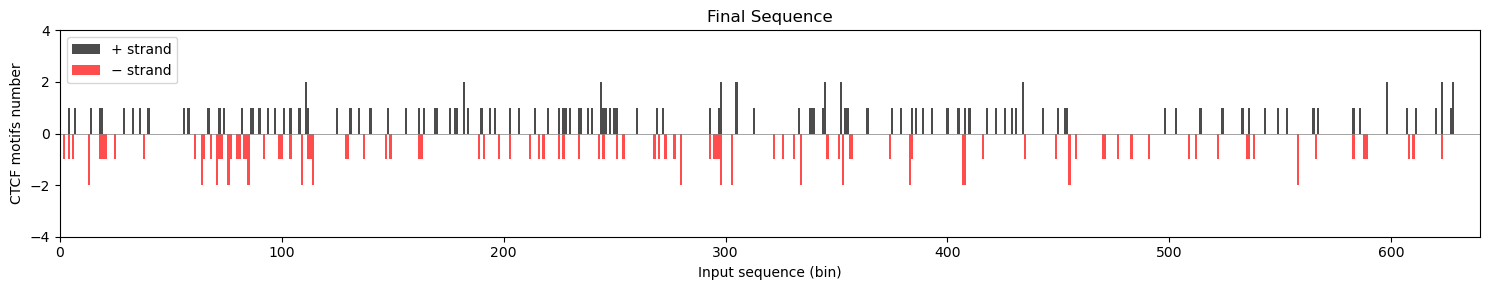

In [24]:
plot_ctcf(ctcf_final_plus, ctcf_final_minus, title="Final Sequence", save_path="./final_seq_ctcf_track.svg")

### Target Seq

In [25]:
target_hits = fimo(
    motifs=motifs_dict,
    sequences=seq_target_tensor.cpu().detach().numpy(),
    threshold=1e-4,
    reverse_complement=True
)[0]

In [26]:
ctcf_target_plus, ctcf_target_minus = ctcf_hits_from_fimo(target_hits)

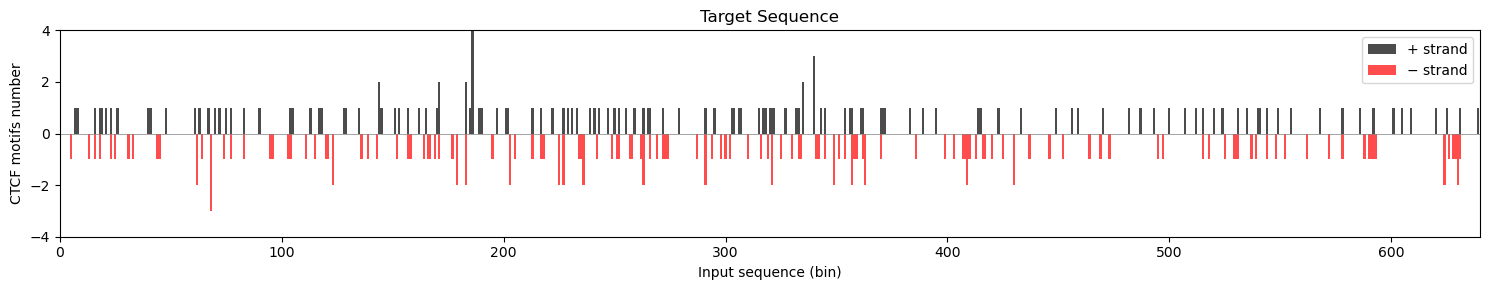

In [27]:
plot_ctcf(ctcf_target_plus, ctcf_target_minus, title="Target Sequence", save_path="./target_seq_ctcf_track.svg")